In [ ]:
import os, re, glob
from collections import defaultdict
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights
from transformers import AutoModelForImageClassification
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Extract patch number from file name
def parse_patch_id(filename):
    name = os.path.splitext(os.path.basename(filename))[0].lower()
    m = re.search(r'(?:^|[_\- ])(?:p|patch)\s*(\d+)$', name)
    return int(m.group(1)) if m else None

def get_group_id(filename):
    base = os.path.splitext(os.path.basename(filename))[0]
    base = re.sub(r'([_\- ]?(p|patch)\s*\d+)$', '', base, flags=re.IGNORECASE)
    return base

class PatchFusionFolder(Dataset):
    def __init__(self, root_dir, transform=None, patches_per_image=4):
        self.transform = transform
        base = ImageFolder(root=root_dir)
        # Store class names and labels
        self.classes = base.classes
        self.class_to_idx = base.class_to_idx

        grouped = defaultdict(list)
        for path, label in base.samples:
            pid = parse_patch_id(path)
            gid = get_group_id(path)
            if pid is not None:
              # Group patches belonging to the same ECG image
                grouped[(label, gid)].append((pid, path))

        # Keep only samples that contain all required patches
        self.items = []
        needed = list(range(1, patches_per_image + 1))
        for (label, gid), lst in grouped.items():
            pid_to_path = {pid: p for pid, p in sorted(lst)}
            if all(n in pid_to_path for n in needed):
                paths = [pid_to_path[n] for n in needed]
                self.items.append((paths, label))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        patch_paths, label = self.items[idx]
        patches = []
        for p in patch_paths:
            img = Image.open(p).convert("RGB")
            if self.transform:
                img = self.transform(img)
            # Load and stack the four patches
            patches.append(img)
        # Shape: (4, 3, 224, 224)
        x = torch.stack(patches, dim=0)
        y = torch.tensor(label, dtype=torch.long)
        return x, y

In [ ]:
# Root directory of the dataset
ROOT = "/content/drive/MyDrive/ProjectDataSet/dataset_split_per_class"

# Image preprocessing pipeline
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load test dataset
test_dataset = PatchFusionFolder(
    root_dir=os.path.join(ROOT, "Test"),
    transform=transform
)
# Create test dataloader
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

# Number of classes
num_classes = len(test_dataset.classes)
print("Classes:", test_dataset.classes)
print("Test samples:", len(test_dataset))


Classes: ['HB', 'MI', 'Normal', 'PMI']
Test samples: 91


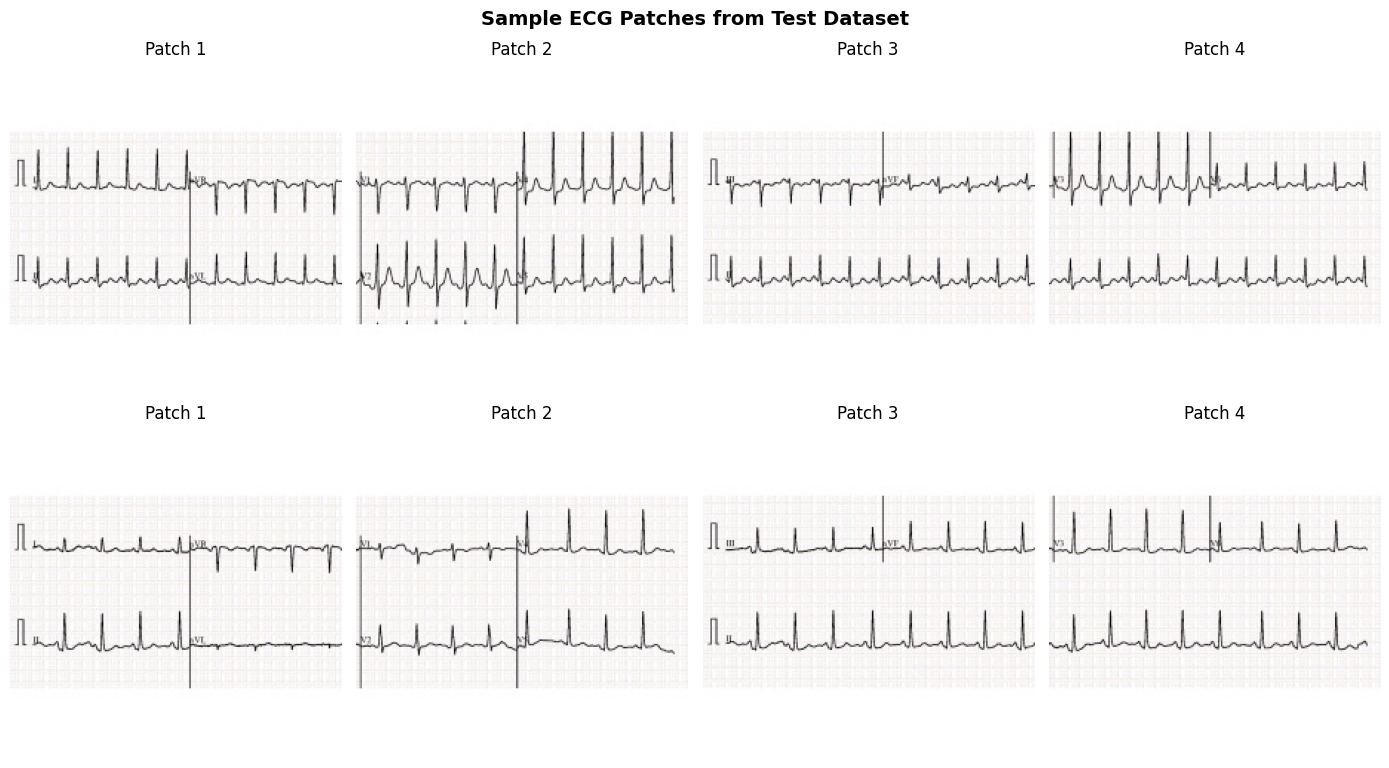

In [ ]:
# Reverse normalization for visualization
#الغاية: ظهور الصورة بدون تشوهات
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

# Number of samples to display
num_samples = 2

fig, axes = plt.subplots(num_samples, 4, figsize=(14, 4 * num_samples))

for row in range(num_samples):
    patches_tensor, label = test_dataset[row]
    for col in range(4):
        img = inv_normalize(patches_tensor[col]).permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        axes[row, col].imshow(img)
        axes[row, col].set_title(f"Patch {col+1}")
        axes[row, col].axis("off")

    axes[row, 0].set_ylabel(
        f"Label: {test_dataset.classes[label]}",
        fontsize=11,
        fontweight="bold",
        rotation=0,
        labelpad=80
    )

plt.suptitle("Sample ECG Patches from Test Dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# MobileNetV3-based patch fusion model
class PatchFusionMobileNetV3(nn.Module):
    def __init__(self, num_classes, fusion="concat", pretrained=False):
        super().__init__()
        weights = MobileNet_V3_Small_Weights.DEFAULT if pretrained else None
        base = mobilenet_v3_small(weights=weights)
        # Feature extractor backbone
        self.features = base.features
        # Global average pooling
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.embed_dim = 576
        self.fusion = fusion.lower()
        fused_dim = self.embed_dim * 4 if self.fusion == "concat" else self.embed_dim
        # Classification head
        self.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(fused_dim, num_classes)
        )

    def forward(self, x):
        B, P, C, H, W = x.shape
        x = x.view(B * P, C, H, W)
        # Extract features from all patches
        f = self.features(x)
        f = self.avgpool(f)
        f = torch.flatten(f, 1)
        # Reshape features back to patch groups
        f_patches = f.view(B, P, -1)
        # Concatenate patch features
        fused = f_patches.reshape(B, -1) if self.fusion == "concat" else f_patches.mean(dim=1)
        # Final classification
        return self.classifier(fused)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# MobileNetV3
mobile_model = PatchFusionMobileNetV3(num_classes=num_classes, fusion="concat").to(device)
# Load trained MobileNetV3 weights
mobile_model.load_state_dict(
    torch.load("/content/drive/MyDrive/Fusion/mobileNetv3_weights.pth", map_location=device)
)
mobile_model.eval()
print("MobileNetV3 loaded ✓")

# Load Swin Tiny model
swin_model = AutoModelForImageClassification.from_pretrained(
    "microsoft/swin-tiny-patch4-window7-224",
    num_labels=num_classes,
    ignore_mismatched_sizes=True
)
# Load trained Swin Tiny checkpoint
checkpoint = torch.load(
    "/content/drive/MyDrive/SA-FUSION/swin_tiny_original_weights.pth",
    map_location=device
)

mapped = {}
for key, value in checkpoint.items():
    new_key = key

    new_key = new_key.replace("attention.q_proj", "attention.self.query")
    new_key = new_key.replace("attention.k_proj", "attention.self.key")
    new_key = new_key.replace("attention.v_proj", "attention.self.value")
    new_key = new_key.replace("attention.o_proj", "attention.output.dense")
    new_key = new_key.replace(
        "attention.relative_position_bias.relative_position_bias_table",
        "attention.self.relative_position_bias_table"
    )
    new_key = new_key.replace(
        "attention.relative_position_bias.relative_position_index",
        "attention.self.relative_position_index"
    )
    new_key = new_key.replace("mlp.fc1", "intermediate.dense")
    new_key = new_key.replace("mlp.fc2", "output.dense")
    mapped[new_key] = value

# Load weights into Swin Tiny
missing, unexpected = swin_model.load_state_dict(mapped, strict=False)
swin_model = swin_model.to(device)
swin_model.eval()
print("Swin Tiny loaded ✓")

MobileNetV3 loaded ✓


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/71.8k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/233 [00:00<?, ?it/s]

SwinForImageClassification LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([4])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([4, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Swin Tiny loaded ✓


In [ ]:
@torch.no_grad()

# Generate probability scores using MobileNetV3
def get_scores_mobile(model, x):
    logits = model(x)
    return F.softmax(logits, dim=1)

@torch.no_grad()
# Generate probability scores using Swin Tiny
def get_scores_swin(model, x):
    B, P, C, H, W = x.shape
    x_flat = x.view(B * P, C, H, W)          # (B*4, 3, 224, 224)
    logits = model(x_flat).logits             # (B*4, num_classes)
    logits = logits.view(B, P, -1).mean(dim=1)  # (B, num_classes)
    return F.softmax(logits, dim=1)

@torch.no_grad()
# Perform Max Score Fusion
def run_max_fusion(mobile_model, swin_model, loader, device):
    mobile_model.eval()
    swin_model.eval()

    all_preds_mobile, all_preds_swin, all_preds_fusion = [], [], []
    all_labels = []
    all_decision_sources = [] # UPDATE: لتتبع الموديل الفائز لكل عينة

    for x, y in loader:
        x = x.to(device)

        # Get MobileNet probabilities
        s_mobile = get_scores_mobile(mobile_model, x)
        # Get Swin Tiny probabilities
        s_swin   = get_scores_swin(swin_model, x)

        # UPDATE: دمج النتائج مع استخراج الـ Indices لمعرفة الموديل صاحب الدرجة الأعلى
        stacked_scores = torch.stack([s_mobile, s_swin], dim=0) # UPDATE
        fused, source_indices = torch.max(stacked_scores, dim=0) # UPDATE

        # UPDATE: تحديد الكلاس النهائي وتحديد الموديل الذي اختاره
        fusion_preds = fused.argmax(dim=1) # UPDATE
        batch_indices = torch.arange(x.size(0), device=device) # UPDATE
        chosen_sources = source_indices[batch_indices, fusion_preds] # UPDATE

        all_preds_mobile.append(s_mobile.argmax(dim=1).cpu())
        all_preds_swin.append(s_swin.argmax(dim=1).cpu())
        all_preds_fusion.append(fusion_preds.cpu()) # UPDATE
        all_decision_sources.append(chosen_sources.cpu()) # UPDATE
        all_labels.append(y)

    all_labels       = torch.cat(all_labels)
    all_preds_mobile = torch.cat(all_preds_mobile)
    all_preds_swin   = torch.cat(all_preds_swin)
    all_preds_fusion = torch.cat(all_preds_fusion)
    all_decision_sources = torch.cat(all_decision_sources) # UPDATE

    # Compute accuracy of each model
    acc_mobile = (all_preds_mobile == all_labels).float().mean().item()
    acc_swin   = (all_preds_swin   == all_labels).float().mean().item()
    acc_fusion = (all_preds_fusion == all_labels).float().mean().item()

    print("\n" + "═" * 45)
    print("       Max Score Fusion — النتائج")
    print("═" * 45)
    print(f"  MobileNetV3  : {acc_mobile*100:.2f}%")
    print(f"  Swin Tiny    : {acc_swin*100:.2f}%")
    print(f"  Max Fusion   : {acc_fusion*100:.2f}%")
    gain = acc_fusion - max(acc_mobile, acc_swin)
    print(f"  الزيادة عن أفضل موديل: {gain*100:+.2f}%")
    print("═" * 45)

    # UPDATE: طباعة إحصائية الاعتماد على الموديلات
    mobilenet_count = (all_decision_sources == 0).sum().item() # UPDATE
    swin_count = (all_decision_sources == 1).sum().item() # UPDATE
    print(f"  الاعتماد على MobileNetV3 في: {mobilenet_count} عينة") # UPDATE
    print(f"  الاعتماد على Swin Tiny في  : {swin_count} عينة") # UPDATE
    print("═" * 45)

    return acc_mobile, acc_swin, acc_fusion

In [ ]:
# Evaluate MobileNetV3, Swin Tiny, and Fusion performance
acc_mobile, acc_swin, acc_fusion = run_max_fusion(
    mobile_model, swin_model, test_loader, device
)



═════════════════════════════════════════════
       Max Score Fusion — النتائج
═════════════════════════════════════════════
  MobileNetV3  : 98.90%
  Swin Tiny    : 97.80%
  Max Fusion   : 97.80%
  الزيادة عن أفضل موديل: -1.10%
═════════════════════════════════════════════
  الاعتماد على MobileNetV3 في: 71 عينة
  الاعتماد على Swin Tiny في  : 20 عينة
═════════════════════════════════════════════


════════════════════════════════════════
     Max Score Fusion — Test Metrics
════════════════════════════════════════
  Accuracy        : 97.80%
  F1 Macro        : 0.9737
  F1 Weighted     : 0.9776
  Precision Macro : 0.9792
  Recall Macro    : 0.9706
════════════════════════════════════════

Detailed Report:
              precision    recall  f1-score   support

          HB       0.96      1.00      0.98        23
          MI       0.96      1.00      0.98        23
      Normal       1.00      1.00      1.00        28
         PMI       1.00      0.88      0.94        17

    accuracy                           0.98        91
   macro avg       0.98      0.97      0.97        91
weighted avg       0.98      0.98      0.98        91



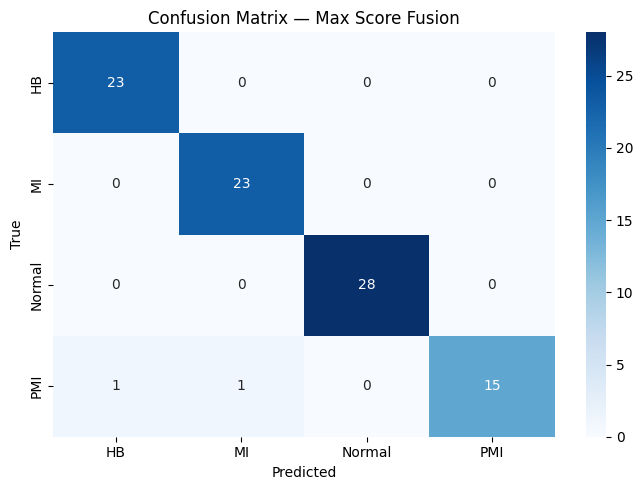

In [ ]:
@torch.no_grad()
# Collect fusion predictions
def get_all_preds(mobile_model, swin_model, loader, device):
    mobile_model.eval()
    swin_model.eval()

    all_labels, all_fusion = [], []

    for x, y in loader:
        x = x.to(device)

        s_mobile = get_scores_mobile(mobile_model, x)
        s_swin   = get_scores_swin(swin_model, x)
        fused    = torch.max(s_mobile, s_swin)

        all_fusion.append(fused.argmax(dim=1).cpu())
        all_labels.append(y)

    return torch.cat(all_labels).numpy(), torch.cat(all_fusion).numpy()

# Generate fusion predictions
y_true, y_pred = get_all_preds(mobile_model, swin_model, test_loader, device)
class_names = test_dataset.classes


acc       = (y_true == y_pred).mean()
f1_macro  = f1_score(y_true, y_pred, average="macro")
f1_weighted = f1_score(y_true, y_pred, average="weighted")
precision = precision_score(y_true, y_pred, average="macro")
recall    = recall_score(y_true, y_pred, average="macro")

print("═" * 40)
print("     Max Score Fusion — Test Metrics")
print("═" * 40)
print(f"  Accuracy        : {acc*100:.2f}%")
print(f"  F1 Macro        : {f1_macro:.4f}")
print(f"  F1 Weighted     : {f1_weighted:.4f}")
print(f"  Precision Macro : {precision:.4f}")
print(f"  Recall Macro    : {recall:.4f}")
print("═" * 40)
print("\nDetailed Report:")
# Print classification report
print(classification_report(y_true, y_pred, target_names=class_names))

# ── Confusion Matrix ───────────────────────────────────
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Max Score Fusion")
plt.tight_layout()


In [ ]:
@torch.no_grad()
def get_all_preds_with_sources(mobile_model, swin_model, loader, device):
    mobile_model.eval()
    swin_model.eval()

    all_labels, all_fusion, all_sources = [], [], []
    all_mobile, all_swin = [], [] # UPDATE: أضفنا هذه لتخزين التوقعات الفردية

    for x, y in loader:
        x = x.to(device)

        s_mobile = get_scores_mobile(mobile_model, x)
        s_swin   = get_scores_swin(swin_model, x)

        # تخزين توقع كل موديل على حدة
        all_mobile.append(s_mobile.argmax(dim=1).cpu())
        all_swin.append(s_swin.argmax(dim=1).cpu())

        stacked_scores = torch.stack([s_mobile, s_swin], dim=0)
        fused, source_indices = torch.max(stacked_scores, dim=0)

        fusion_preds = fused.argmax(dim=1)
        batch_indices = torch.arange(x.size(0), device=device)
        chosen_sources = source_indices[batch_indices, fusion_preds]

        all_fusion.append(fusion_preds.cpu())
        all_sources.append(chosen_sources.cpu())
        all_labels.append(y)

    # نعيد 5 قيم الآن بدلاً من 3
    return (torch.cat(all_labels).numpy(),
            torch.cat(all_fusion).numpy(),
            torch.cat(all_sources).numpy(),
            torch.cat(all_mobile), # التوقعات الفردية للموبايل
            torch.cat(all_swin))  # التوقعات الفردية للسوين

In [ ]:
# تنفيذ الاستخراج - هنا يتم الربط الفعلي
y_true, y_pred, y_sources, all_preds_mobile, all_preds_swin = get_all_preds_with_sources(
        mobile_model, swin_model, test_loader, device
)

In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 34.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=c868aea731a37512e4e53c970cfd14900db245113fbe1dab6c75c1c72d32c598
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
from pytorch_grad_cam import EigenCAM
from pytorch_grad_cam.utils.reshape_transforms import swinT_reshape_transform

class SwinWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        return self.model(x).logits

def get_swin_attention_map(model, pixel_values, device):
    wrapped = SwinWrapper(model).to(device)
    wrapped.eval()

    target_layer = wrapped.model.swin.encoder.layers[-1].blocks[-1].layernorm_before

    cam = EigenCAM(
        model=wrapped,
        target_layers=[target_layer],
        reshape_transform=swinT_reshape_transform
    )

    grayscale_cam = cam(input_tensor=pixel_values.to(device))[0, :]
    return grayscale_cam

In [ ]:
def show_swin_xai(model, patches_tensor, label, classes, device):

    def unnormalize(img_tensor):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        img = img_tensor.cpu() * std + mean
        return torch.clamp(img, 0, 1)

    model.eval()
    class_name = classes[label if isinstance(label, int) else label.item()]
    print(f"--- Class: {class_name}")

    imgs_rgb  = []
    cams_gray = []

    for i in range(4):
        single_patch = patches_tensor[i].unsqueeze(0).to(device)
        heatmap = get_swin_attention_map(model, single_patch, device)
        img_rgb = unnormalize(patches_tensor[i]).permute(1, 2, 0).cpu().numpy()
        img_rgb = np.clip(img_rgb, 0, 1)
        imgs_rgb.append(img_rgb)
        cams_gray.append(heatmap)

    top_img    = np.concatenate([imgs_rgb[0],  imgs_rgb[1]],  axis=1)
    bottom_img = np.concatenate([imgs_rgb[2],  imgs_rgb[3]],  axis=1)
    full_img   = np.concatenate([top_img, bottom_img],        axis=0)

    top_cam    = np.concatenate([cams_gray[0], cams_gray[1]], axis=1)
    bottom_cam = np.concatenate([cams_gray[2], cams_gray[3]], axis=1)
    full_cam   = np.concatenate([top_cam, bottom_cam],        axis=0)

    import cv2
    full_cam_smooth = cv2.GaussianBlur(full_cam, (21, 21), sigmaX=8)

    full_visualization = show_cam_on_image(full_img, full_cam_smooth, use_rgb=True)

    fig, axes = plt.subplots(1, 1, figsize=(6, 5))
    axes.imshow(full_visualization)
    axes.set_title("EigenCAM", fontsize=10, weight='bold')
    axes.axis('off')

    plt.suptitle(f"Swin XAI Interpretation | Diagnosis: {class_name}", fontsize=14, weight='bold')
    plt.tight_layout()
    plt.savefig(f"/content/drive/MyDrive/eigencam_{class_name}.png", dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
#مباشرة حقت القراد كام
# UPDATE: عدلت 3 أشياء:
# 1. اسم الموديل: model = mobile_model
# 2. اسم الداتاسيت: test_ds = test_dataset
# 3. الدالة صارت تقبل idx محدد بدل عشوائي دايماً
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import random
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# Wrapper يحوّل features إلى vector (scalar output per channel)
class MobileNetFeaturesWrapper(nn.Module):
    def __init__(self, features, avgpool): # تصحيح dunder init ليعمل الكود
        super().__init__()
        self.features = features
        self.avgpool  = avgpool

    def forward(self, x):
        x = self.features(x)   # (1, 576, h, w)
        x = self.avgpool(x)    # (1, 576, 1, 1)
        x = torch.flatten(x, 1)  # (1, 576)
        return x

def unnormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img = img_tensor.cpu() * std + mean
    return torch.clamp(img, 0, 1)


def generate_gradcam_honest(idx=None):
      # التعديل: تغيير model إلى mobile_model
    mobile_model.eval()

    # التعديل: تغيير test_ds إلى test_dataset
    if idx is None:
     idx = random.randint(0, len(test_dataset) - 1)
    # التعديل: استلام عنصرين فقط كما في تعريف PatchFusionFolder
    patches_tensor, y_sample = test_dataset[idx]
    class_text_name = test_dataset.classes[y_sample if isinstance(y_sample, int) else y_sample.item()]
    # التعديل: حذف bid لأنه غير موجود في مخرجات الـ Dataset الحالية
    print(f"--- Patient Index: {idx} | Class: {class_text_name}")

    # التعديل: تغيير model إلى mobile_model
    wrapper = MobileNetFeaturesWrapper(mobile_model.features, mobile_model.avgpool).to(device)
    wrapper.eval()
    for param in wrapper.parameters():
        param.requires_grad = True

    cam = GradCAM(model=wrapper, target_layers=[wrapper.features[-1]])

    imgs_rgb  = []
    cams_gray = []

    for i in range(4):
        single_patch = patches_tensor[i].unsqueeze(0).to(device)
        grayscale_cam = cam(input_tensor=single_patch, targets=None)[0, :]  # (224,224)
        img_rgb = unnormalize(patches_tensor[i]).permute(1, 2, 0).numpy()
        imgs_rgb.append(img_rgb)
        cams_gray.append(grayscale_cam)

    # ─── دمج بصري فقط بعد الحساب ───
    top_img    = np.concatenate([imgs_rgb[0],  imgs_rgb[1]],  axis=1)
    bottom_img = np.concatenate([imgs_rgb[2],  imgs_rgb[3]],  axis=1)
    full_img   = np.concatenate([top_img, bottom_img],        axis=0)

    top_cam    = np.concatenate([cams_gray[0], cams_gray[1]], axis=1)
    bottom_cam = np.concatenate([cams_gray[2], cams_gray[3]], axis=1)
    full_cam   = np.concatenate([top_cam, bottom_cam],        axis=0)

    import cv2
    full_cam_smooth = cv2.GaussianBlur(full_cam, (21, 21), sigmaX=8)

    full_visualization = show_cam_on_image(full_img, full_cam_smooth, use_rgb=True)

    fig, axes = plt.subplots(1, 1, figsize=(6, 5))
    axes.imshow(full_visualization)
    axes.set_title("Grad-CAM", fontsize=10, weight='bold')
    axes.axis('off')

    plt.suptitle(f"Grad-CAM | Diagnosis: {class_text_name}", fontsize=14, weight='bold')
    plt.tight_layout()
    plt.savefig(f"/content/drive/MyDrive/gradcam_{class_text_name}.png", dpi=150, bbox_inches='tight')
    plt.show()


True: MI
Fusion chose: Mobile ✓
--- Patient Index: 36 | Class: MI


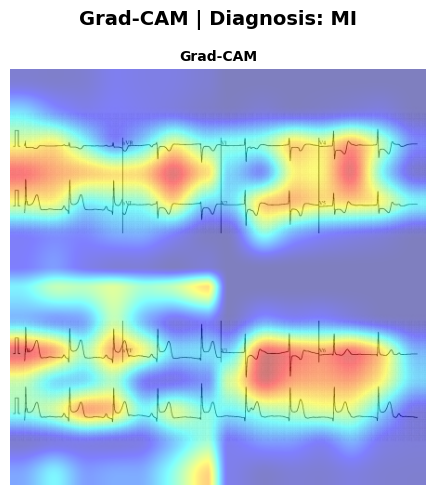

In [ ]:
# عينة اعتمد فيها الفيوجن على قرارالموبايل
# راح تظهر صورة عشوائئية مع كل رن من ال71 عينة الي اعتمد فيها الفيوجن على قررار ورؤية الموبايل فيها

valid = np.where(y_sources == 0)[0]
mobile_idx = int(random.choice(valid))

print(f"True: {test_dataset.classes[y_true[mobile_idx]]}")
print(f"Fusion chose: Mobile ✓")

generate_gradcam_honest(mobile_idx)

True: PMI
Fusion chose: Swin ✓
--- Class: PMI


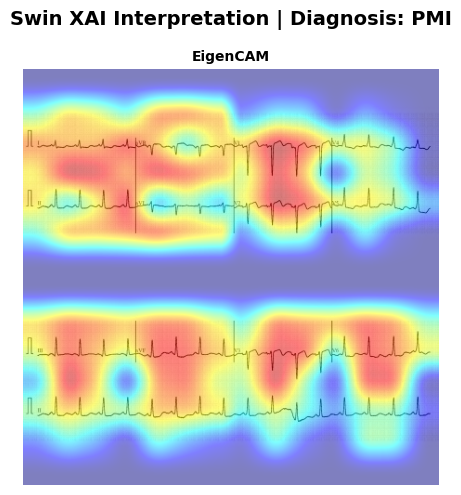

In [ ]:
# عينة اعتمد فيها الفيوجن على قرار السوين
# راح تظهر صورة عشوائئية مع كل رن من ال20 عينة الي اعتمد فيها الفيوجن على قررار ورؤية السوين فيها
valid = np.where(y_sources == 1)[0]
swin_idx = int(random.choice(valid))

patches_tensor, label = test_dataset[swin_idx]
print(f"True: {test_dataset.classes[y_true[swin_idx]]}")
print(f"Fusion chose: Swin ✓")

show_swin_xai(swin_model, patches_tensor, label, test_dataset.classes, device)